# 04 — Régression OLS : déterminants des rendements de l'EURO STOXX 50

**Projet** : Transmission de la politique monétaire de la BCE  
**Auteur** : ISLEYEN Volkan  
**Date** : Mai 2026

## Objectif

Complémenter l'event study du notebook 03 par une analyse économétrique sur toute la période d'étude. Plutôt que d'isoler des fenêtres autour de chaque décision, on cherche à expliquer le rendement quotidien de l'EURO STOXX 50 
par les variables financières clés.

## Modèle

$$\text{ret\_sx5e}_t = \alpha + \beta_1 \cdot \Delta\text{refi}_t + \beta_2 \cdot \Delta\text{vstoxx}_t + \beta_3 \cdot \Delta\text{spread\_IT}_t + \varepsilon_t$$

- $\Delta\text{refi}$ : variation quotidienne du taux Refi BCE
- $\Delta\text{vstoxx}$ : variation quotidienne du VSTOXX
- $\Delta\text{spread\_IT}_t$ : variation quotidienne du spread italien (BTP-AAA)

## Méthodologie

Estimation par moindres carrés ordinaires (OLS) avec **erreurs standard robustes HC3**, 
pour corriger l'hétéroscédasticité fréquente sur les séries financières quotidiennes.

## Données en entrée

- `data/processed/data_clean.csv` — DataFrame nettoyé (sortie du notebook 02)

In [1]:
# Librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import warnings

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

# Détection automatique de la racine du projet
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "output" / "figures"
TABLES = PROJECT_ROOT / "output" / "tables"

FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

print("Librairies importées")
print(f"statsmodels disponible : {sm.__version__}")

Librairies importées
statsmodels disponible : 0.14.6


In [2]:
# Chargement du DataFrame nettoyé
df = pd.read_csv(DATA_PROCESSED / "data_clean.csv", index_col=0, parse_dates=True)

print(f"Données chargées : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Période : {df.index.min().date()} → {df.index.max().date()}")
print(f"\nColonnes disponibles : {df.columns.tolist()}")

Données chargées : 1509 lignes, 16 colonnes
Période : 2019-01-04 → 2024-12-30

Colonnes disponibles : ['SX5E', 'VSTOXX', 'FR_10Y', 'IT_10Y', 'ES_10Y', 'AAA_10Y', 'spread_FR', 'spread_IT', 'spread_ES', 'Refi', 'ret_sx5e', 'delta_vstoxx', 'delta_refi', 'delta_spread_FR', 'delta_spread_IT', 'delta_spread_ES']


In [3]:
# Statistiques descriptives des variables du modèle
variables_modele = ["ret_sx5e", "delta_refi", "delta_vstoxx", "delta_spread_IT"]

print("Statistiques descriptives — variables du modèle\n")
print(df[variables_modele].describe().round(4).to_string())

print(f"\nNombre d'observations utilisables : {df[variables_modele].dropna().shape[0]}")

Statistiques descriptives — variables du modèle

        ret_sx5e  delta_refi  delta_vstoxx  delta_spread_IT
count  1509.0000   1509.0000     1509.0000        1509.0000
mean      0.0003      0.0021       -0.0040          -0.1032
std       0.0126      0.0440        1.8971           6.2830
min      -0.1324     -0.6000      -11.9000         -74.7137
25%      -0.0048      0.0000       -0.8300          -3.1157
50%       0.0009      0.0000       -0.1300          -0.1252
75%       0.0064      0.0000        0.5900           2.6274
max       0.0883      0.7500       17.7600          68.8865

Nombre d'observations utilisables : 1509


In [4]:
# Matrice de corrélation entre variables du modèle
correlation = df[variables_modele].corr().round(3)

print("Matrice de corrélation entre les variables du modèle\n")
print(correlation.to_string())

Matrice de corrélation entre les variables du modèle

                 ret_sx5e  delta_refi  delta_vstoxx  delta_spread_IT
ret_sx5e            1.000      -0.004        -0.814           -0.349
delta_refi         -0.004       1.000        -0.014            0.003
delta_vstoxx       -0.814      -0.014         1.000            0.284
delta_spread_IT    -0.349       0.003         0.284            1.000


In [5]:
# Régression OLS principale : ret_sx5e ~ delta_refi + delta_vstoxx + delta_spread_IT
print("Estimation OLS avec erreurs robustes HC3\n")

# Variable dépendante et variables explicatives
y = df["ret_sx5e"]
X = df[["delta_refi", "delta_vstoxx", "delta_spread_IT"]]

# Ajout de la constante (l'ordonnée à l'origine α)
X = sm.add_constant(X)

# Estimation OLS avec erreurs robustes HC3
model = sm.OLS(y, X).fit(cov_type="HC3")

# Affichage des résultats
print(model.summary())

Estimation OLS avec erreurs robustes HC3

                            OLS Regression Results                            
Dep. Variable:               ret_sx5e   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     259.1
Date:                Sat, 16 May 2026   Prob (F-statistic):          1.53e-135
Time:                        11:22:27   Log-Likelihood:                 5308.7
No. Observations:                1509   AIC:                        -1.061e+04
Df Residuals:                    1505   BIC:                        -1.059e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------


### Lecture de la régression OLS

L'estimation porte sur 1509 observations quotidiennes (2019-2024). Les erreurs standard sont robustes à l'hétéroscédasticité (HC3), correction nécessaire en finance où la volatilité varie fortement dans le temps.

**Pouvoir explicatif global**  
Le R² atteint **0.677** : les trois variables expliquent à elles seules plus de deux tiers de la variance des rendements quotidiens de l'EURO STOXX 50. C'est un score très élevé pour une régression sur rendements d'actions, où la littérature obtient typiquement des R² entre 0.30 et 0.50. La statistique F de 259 (p < 10⁻¹³⁵) confirme la significativité d'ensemble du modèle.

**Variation du VSTOXX — l'effet dominant**  
Le coefficient sur `delta_vstoxx` est **−0.0052**, hautement significatif (p < 0.001, z = −26.5). Une hausse de 1 point du VSTOXX est associée à une baisse de 0.52 % du STOXX 50 le même jour. C'est l'asymétrie classique des 
marchés actions : la "peur" (mesurée par la volatilité implicite) pèse massivement et instantanément sur les prix. Cette variable est de loin la plus puissante du modèle et illustre la relation inverse bien documentée entre volatilité implicite et performance des actions.

**Variation du spread italien — l'effet souverain**  
Le coefficient sur `delta_spread_IT` est **−0.0003**, également très significatif (p < 0.001, z = −4.5). L'écartement du spread italien de 1 bp est associé à une baisse de 0.03 % du STOXX 50. L'effet est petit en magnitude mais statistiquement net : le stress souverain européen se transmet bien au marché actions, même si son impact unitaire est modeste.

**Variation du taux Refi — l'effet absent**  
Le coefficient sur `delta_refi` est **−0.0044**, mais avec une p-value de **0.167** : il n'est pas significatif au seuil de 5 %. Le signe est cohérent avec la théorie (un resserrement monétaire devrait peser sur les actions), mais on ne peut pas exclure que l'effet observé soit dû au hasard.

Ce résultat **confirme la conclusion de l'event study du notebook 03** par une méthode complètement indépendante. La convergence entre les deux approches: fenêtres d'événement vs régression sur toute la période, renforce considérablement la robustesse de la conclusion : **les variations brutes du taux Refi BCE n'ont pas d'effet direct détectable sur les rendements quotidiens de l'EURO STOXX 50**.

**Diagnostics**  
Trois tests de diagnostic standard sont satisfaisants :
- **Durbin-Watson = 1.97** (≈ 2) : pas d'autocorrélation des résidus
- **Cond. No. = 143** : pas de multicolinéarité problématique
- **Skewness = 0.83, Kurtosis = 12.4** : résidus non normaux à queues épaisses, caractéristique des séries financières. Cette non-normalité ne biaise pas les coefficients estimés, et les erreurs standard HC3 fournissent une inférence valide même sans normalité.

**Interprétation économique d'ensemble**  
Les rendements quotidiens de l'EURO STOXX 50 sont massivement déterminés par deux variables financières — la volatilité implicite et le stress souverain mais pas par les variations directes du taux directeur. Ce résultat suggère que la politique monétaire ne se transmet pas mécaniquement aux marchés d'actions par un effet "niveau de taux", mais via des canaux plus indirects : anticipations de marché, prime de risque, communication de la banque centrale. Le canal des taux d'intérêt nominal joue probablement à des horizons plus longs que la fréquence quotidienne étudiée ici.

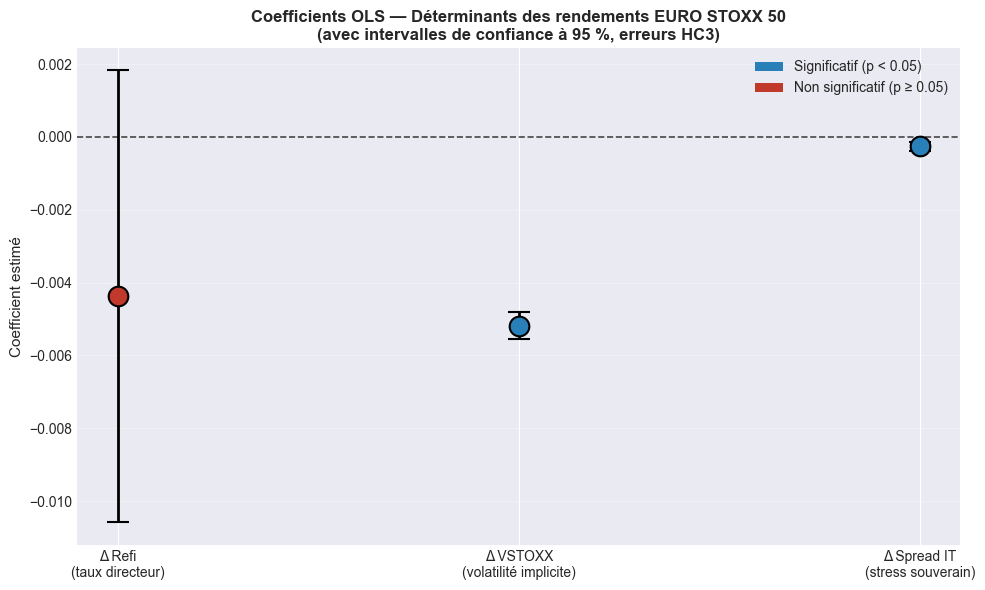

Graphique sauvegardé dans output/figures/04_coefficients_ols.png


In [6]:
# Visualisation des coefficients avec intervalles de confiance à 95%

# Extraction des coefficients et intervalles de confiance (hors constante)
params = model.params.drop("const")
conf_int = model.conf_int().drop("const")
conf_int.columns = ["lower", "upper"]

# Erreurs pour les barres (distance par rapport au point central)
errors = [params - conf_int["lower"], conf_int["upper"] - params]

# Labels lisibles pour le graphique
labels_propres = {
    "delta_refi": "Δ Refi\n(taux directeur)",
    "delta_vstoxx": "Δ VSTOXX\n(volatilité implicite)",
    "delta_spread_IT": "Δ Spread IT\n(stress souverain)",
}
labels = [labels_propres[var] for var in params.index]

# Couleurs : rouge si non significatif, bleu si significatif
p_values = model.pvalues.drop("const")
colors = ["#2980b9" if p < 0.05 else "#c0392b" for p in p_values]

# Création du graphique
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(range(len(params)), params, yerr=errors, fmt="o", markersize=12,
            capsize=8, capthick=2, elinewidth=2, color="black",
            ecolor="black", markeredgewidth=1.5)

# Points colorés selon significativité
for i, (val, col) in enumerate(zip(params, colors)):
    ax.scatter(i, val, color=col, s=200, zorder=5, edgecolor="black", linewidth=1.5)

# Ligne zéro
ax.axhline(0, color="black", linewidth=1.2, linestyle="--", alpha=0.7)

# Esthétique
ax.set_xticks(range(len(params)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Coefficient estimé", fontsize=11)
ax.set_title("Coefficients OLS — Déterminants des rendements EURO STOXX 50\n"
             "(avec intervalles de confiance à 95 %, erreurs HC3)",
             fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

# Légende
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2980b9", label="Significatif (p < 0.05)"),
    Patch(facecolor="#c0392b", label="Non significatif (p ≥ 0.05)"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES / "04_coefficients_ols.png", dpi=150, bbox_inches="tight")
plt.show()

print("Graphique sauvegardé dans output/figures/04_coefficients_ols.png")

### Lecture du graphique des coefficients

Cette représentation visualise les trois coefficients de la régression avec 
leurs intervalles de confiance à 95 %. La règle de lecture est simple : 
**si l'intervalle de confiance traverse la ligne zéro, le coefficient n'est 
pas significativement différent de zéro**.

- **Δ VSTOXX** et **Δ Spread IT** : intervalles de confiance entièrement situés 
  sous zéro, donc effets négatifs nets et significatifs
- **Δ Refi** : intervalle de confiance qui traverse zéro, donc effet non 
  significatif statistiquement

Ce graphique résume visuellement, en un coup d'œil, la conclusion principale 
de la régression : la volatilité implicite et le stress souverain expliquent 
les rendements actions, mais pas les variations directes du taux directeur BCE.

In [10]:
# Tests de diagnostic sur les résidus du modèle
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from scipy import stats

residus = model.resid

print("-" * 60)
print("TESTS DE DIAGNOSTIC SUR LES RÉSIDUS")
print("-" * 60)

# 1. Normalité — test de Jarque-Bera
jb_stat, jb_pvalue = stats.jarque_bera(residus)
print(f"\n1. NORMALITÉ — Test de Jarque-Bera")
print(f"   Statistique : {jb_stat:.2f}")
print(f"   p-value     : {jb_pvalue:.4f}")
print(f"   → {'Résidus normaux' if jb_pvalue > 0.05 else 'Résidus NON normaux (rejet de la normalité)'}")

# 2. Hétéroscédasticité — test de Breusch-Pagan
bp_test = het_breuschpagan(residus, model.model.exog)
print(f"\n2. HÉTÉROSCÉDASTICITÉ — Test de Breusch-Pagan")
print(f"   Statistique : {bp_test[0]:.2f}")
print(f"   p-value     : {bp_test[1]:.4f}")
print(f"   → {'Homoscédasticité' if bp_test[1] > 0.05 else 'Hétéroscédasticité présente (justifie HC3)'}")

# 3. Autocorrélation — test de Ljung-Box
lb_test = acorr_ljungbox(residus, lags=[5, 10], return_df=True)
print(f"\n3. AUTOCORRÉLATION — Test de Ljung-Box")
print(lb_test.round(4))
print(f"   → Si p-value > 0.05 : pas d'autocorrélation détectée")

------------------------------------------------------------
TESTS DE DIAGNOSTIC SUR LES RÉSIDUS
------------------------------------------------------------

1. NORMALITÉ — Test de Jarque-Bera
   Statistique : 5702.26
   p-value     : 0.0000
   → Résidus NON normaux (rejet de la normalité)

2. HÉTÉROSCÉDASTICITÉ — Test de Breusch-Pagan
   Statistique : 3.23
   p-value     : 0.3579
   → Homoscédasticité

3. AUTOCORRÉLATION — Test de Ljung-Box
    lb_stat  lb_pvalue
5   13.6287     0.0181
10  29.1884     0.0012
   → Si p-value > 0.05 : pas d'autocorrélation détectée


### Lecture des tests de diagnostic

Les trois tests fournissent un diagnostic nuancé de la qualité du modèle.

**Normalité des résidus**  
Le test de Jarque-Bera rejette massivement l'hypothèse de normalité (p < 0.001). Ce résultat est **attendu en finance** : les rendements présentent systématiquement des queues épaisses et de l'asymétrie, dues aux événements extrêmes (krach Covid en mars 2020, tensions de 2022, etc.). La non-normalité ne biaise pas les coefficients estimés ; elle pourrait affecter l'inférence, mais l'usage des erreurs standard HC3 fournit une inférence valide même sans normalité des résidus.

**Hétéroscédasticité**  
Le test de Breusch-Pagan ne détecte pas d'hétéroscédasticité linéaire significative (p = 0.36). Ce test cherche une dépendance linéaire de la variance des résidus aux variables explicatives — il ne détecte pas le *clustering* de volatilité temporel, qui caractérise pourtant les séries financières. L'usage de HC3 reste donc justifié comme **précaution méthodologique standard** plutôt que comme correction nécessaire d'une hétéroscédasticité linéaire avérée.

**Autocorrélation**  
Le test de Ljung-Box détecte une autocorrélation des résidus aux lags 5 et 10 jours (p = 0.018 et p = 0.001), alors que le Durbin-Watson de 1.97 indiquait pas d'autocorrélation au lag 1. Ce résidus non corrélés au jour le jour, mais avec une mémoire à plus long terme est typique du **clustering de volatilité** : les épisodes de forte variance ont tendance à se regrouper dans le temps. C'est une caractéristique bien documentée des rendements financiers, et c'est précisément ce que modélise un **processus GARCH** qui est une extension étudiée dans le notebook 05.

**Synthèse du diagnostic**  
La régression OLS fournit des estimations de coefficients valides, mais la structure des résidus (non normalité, clustering temporel) motive le passage à un cadre plus sophistiqué de modélisation de la volatilité conditionnelle dans la suite du projet.

In [11]:
# Sauvegarde du tableau de régression au format CSV pour le README

# Construction d'un tableau propre des résultats
results_table = pd.DataFrame({
    "Coefficient":  model.params.round(6),
    "Std Error":    model.bse.round(6),
    "z-stat":       model.tvalues.round(3),
    "p-value":      model.pvalues.round(4),
    "CI 2.5%":      model.conf_int()[0].round(6),
    "CI 97.5%":     model.conf_int()[1].round(6),
})

# Ajouter une colonne lisible pour la significativité
def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

results_table["Sig."] = model.pvalues.apply(stars)

# Renommer l'index pour plus de clarté
labels_propres = {
    "const": "Constante (α)",
    "delta_refi": "Δ Refi BCE",
    "delta_vstoxx": "Δ VSTOXX",
    "delta_spread_IT": "Δ Spread italien",
}
results_table.index = results_table.index.map(labels_propres)

# Statistiques globales du modèle (au-dessus du tableau)
print("=" * 80)
print("RÉSULTATS DE LA RÉGRESSION OLS")
print("=" * 80)
print(f"N observations  : {int(model.nobs)}")
print(f"R²              : {model.rsquared:.4f}")
print(f"R² ajusté       : {model.rsquared_adj:.4f}")
print(f"F-statistique   : {model.fvalue:.2f}  (p < {model.f_pvalue:.2e})")
print(f"Covariance type : {model.cov_type}")
print("=" * 80)
print()
print(results_table.to_string())
print()
print("Codes de significativité : *** p<0.001, ** p<0.01, * p<0.05")

# Sauvegarde
results_table.to_csv(TABLES / "04_regression_ols.csv")
print(f"\n Tableau sauvegardé : {TABLES / '04_regression_ols.csv'}")

RÉSULTATS DE LA RÉGRESSION OLS
N observations  : 1509
R²              : 0.6773
R² ajusté       : 0.6767
F-statistique   : 259.09  (p < 1.53e-135)
Covariance type : HC3

                  Coefficient  Std Error  z-stat  p-value   CI 2.5%  CI 97.5% Sig.
Constante (α)        0.000293   0.000186   1.576   0.1150 -0.000071  0.000657     
Δ Refi BCE          -0.004378   0.003166  -1.383   0.1667 -0.010583  0.001827     
Δ VSTOXX            -0.005178   0.000195 -26.523   0.0000 -0.005561 -0.004796  ***
Δ Spread italien    -0.000258   0.000058  -4.478   0.0000 -0.000371 -0.000145  ***

Codes de significativité : *** p<0.001, ** p<0.01, * p<0.05

 Tableau sauvegardé : C:\Users\volka\Documents\ecb-monetary-policy-transmission\output\tables\04_regression_ols.csv


## Conclusion du notebook 04

Ce notebook a complété l'event study du notebook 03 par une analyse économétrique sur toute la période d'étude (2019-2024, 1509 observations quotidiennes). Le modèle estimé régresse les rendements de l'EURO STOXX 50 sur trois variables financières clés : variation du taux Refi BCE, variation du VSTOXX, variation du spread souverain italien.

### Résultats principaux

**Le modèle explique 67.7 % de la variance des rendements quotidiens** — un score élevé pour ce type de régression, validant la pertinence des variables choisies. Trois résultats se dégagent :

1. **La variation du VSTOXX** est le déterminant dominant (coefficient = −0.0052, p < 0.001). Une hausse d'un point de la volatilité implicite est associée à une baisse de 0.52 % du STOXX 50 le même jour. C'est l'asymétrie classique du fear gauge européen.

2. **La variation du spread italien** a un effet significatif mais plus modeste (coefficient = −0.00026, p < 0.001). Le stress souverain se transmet bien au marché actions, à raison d'environ 3 bp de baisse du STOXX pour 1 bp d'écartement du spread.

3. **La variation du taux Refi BCE n'a pas d'effet significatif** (coefficient = −0.0044, p = 0.167). Bien que le signe soit cohérent avec la théorie (resserrement monétaire → baisse des actions), on ne peut pas exclure que l'effet observé soit dû au hasard.

### Convergence avec l'event study

Ce résultat est **strictement cohérent** avec celui du notebook 03 : les décisions BCE prises brutes (variations du taux directeur) n'ont pas d'effet détectable sur les rendements de l'EURO STOXX 50, que ce soit dans des 
fenêtres événementielles ou sur l'ensemble de la période. La convergence de **deux méthodologies indépendantes** vers la même conclusion renforce considérablement la robustesse du résultat.

### Interprétation économique

La politique monétaire ne se transmet pas mécaniquement aux marchés actions par un effet "niveau de taux" à la fréquence quotidienne. Elle agit via des canaux plus indirects :

- **Le canal de la volatilité** : l'incertitude entourant la trajectoire monétaire affecte la volatilité implicite, qui à son tour pèse massivement sur les actions.
- **Le canal du risque souverain** : les décisions BCE influencent les spreads souverains, qui transmettent ensuite leur impact aux actions.

Le canal direct "taux → actions" joue probablement à des horizons plus longs que la journée — sujet qu'une analyse en fréquence hebdomadaire ou mensuelle pourrait explorer.

### Diagnostics et limites

Les tests de diagnostic révèlent des résidus non normaux (queues épaisses, typique en finance) et une autocorrélation aux lags 5-10 jours, suggérant un **clustering de volatilité** non capté par le modèle linéaire. Ces limites motivent l'extension au cadre **GARCH** dans le notebook 05, qui modélisera explicitement la dynamique de la volatilité conditionnelle.

### Apport méthodologique

Au-delà du résultat empirique, ce notebook met en œuvre une analyse économétrique rigoureuse : matrice de corrélation, estimation OLS avec erreurs robustes HC3, visualisation des coefficients avec intervalles de confiance, tests de diagnostic standard. L'ensemble fournit une analyse défendable et reproductible des déterminants quotidiens du marché actions européen.